FixMatch (Semi Supervised Learning) Model Implementation: Training with PlantVillage and using the trained model on PlantDoc

In [69]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
from PIL import Image
from tqdm import tqdm

# 1. SETUP DEVICE & HYPERPARAMETERIZATION 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 5
batch_size = 16
learning_rate = 1e-4 

Mapping PlantVillage and PlantDoc

In [70]:
import os

# Update these paths to your actual folders
target_path = "c:/Users/user/OneDrive/Desktop/fall 2025/Spring 2026/PlantDiseaseProject/data/plantdoc/test/"

if os.path.exists(target_path):
    target_folders = sorted([f for f in os.listdir(target_path) if os.path.isdir(os.path.join(target_path, f))])
    
    print("Copy and paste this into your script and fill in the Source names:\n")
    print("label_map = {")
    for folder in target_folders:
        
        if "tomato" in folder.lower() or "pepper" in folder.lower():
            print(f"    '{folder}': 'FILL_IN_PLANT_VILLAGE_NAME',")
    print("}")
else:
    print("Target path not found.")

Copy and paste this into your script and fill in the Source names:

label_map = {
    'Bell_pepper leaf': 'FILL_IN_PLANT_VILLAGE_NAME',
    'Bell_pepper leaf spot': 'FILL_IN_PLANT_VILLAGE_NAME',
    'Tomato Early blight leaf': 'FILL_IN_PLANT_VILLAGE_NAME',
    'Tomato Septoria leaf spot': 'FILL_IN_PLANT_VILLAGE_NAME',
    'Tomato leaf': 'FILL_IN_PLANT_VILLAGE_NAME',
    'Tomato leaf bacterial spot': 'FILL_IN_PLANT_VILLAGE_NAME',
    'Tomato leaf late blight': 'FILL_IN_PLANT_VILLAGE_NAME',
    'Tomato leaf mosaic virus': 'FILL_IN_PLANT_VILLAGE_NAME',
    'Tomato leaf yellow virus': 'FILL_IN_PLANT_VILLAGE_NAME',
    'Tomato mold leaf': 'FILL_IN_PLANT_VILLAGE_NAME',
}


In [71]:
import os

source_path = "c:/Users/user/OneDrive/Desktop/fall 2025/Spring 2026/PlantDiseaseProject/data/plantvillage/"

if os.path.exists(source_path):
    # Get all folder names in the source directory
    source_folders = sorted([f for f in os.listdir(source_path) if os.path.isdir(os.path.join(source_path, f))])
    
    print("--- EXACT PLANT VILLAGE FOLDER NAMES ---")
    for folder in source_folders:
        # We use repr() to show any hidden spaces, though unlikely
        print(f"'{folder}'")
else:
    print(f"Path not found: {source_path}")

--- EXACT PLANT VILLAGE FOLDER NAMES ---
'Pepper__bell___Bacterial_spot'
'Pepper__bell___healthy'
'Potato___Early_blight'
'Potato___Late_blight'
'Potato___healthy'
'Tomato_Bacterial_spot'
'Tomato_Early_blight'
'Tomato_Late_blight'
'Tomato_Leaf_Mold'
'Tomato_Septoria_leaf_spot'
'Tomato_Spider_mites_Two_spotted_spider_mite'
'Tomato__Target_Spot'
'Tomato__Tomato_YellowLeaf__Curl_Virus'
'Tomato__Tomato_mosaic_virus'
'Tomato_healthy'


The Master Label Map: Connects plantdoc file names to plantvillage

In [72]:

label_map = {
    'Bell_pepper leaf': 'Pepper__bell___healthy',
    'Bell_pepper leaf spot': 'Pepper__bell___Bacterial_spot',
    'Tomato Early blight leaf': 'Tomato_Early_blight',
    'Tomato Septoria leaf spot': 'Tomato_Septoria_leaf_spot',
    'Tomato leaf': 'Tomato_healthy',
    'Tomato leaf bacterial spot': 'Tomato_Bacterial_spot',
    'Tomato leaf late blight': 'Tomato_Late_blight',
    'Tomato leaf mosaic virus': 'Tomato__Tomato_mosaic_virus',
    'Tomato leaf yellow virus': 'Tomato__Tomato_YellowLeaf__Curl_Virus',
    'Tomato mold leaf': 'Tomato_Leaf_Mold',
}

Transforms

In [73]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Source Dataset: PlantVillage

In [74]:
#Source Dataset
source_path = "c:/Users/user/OneDrive/Desktop/fall 2025/Spring 2026/PlantDiseaseProject/data/plantvillage/"
source_dataset = datasets.ImageFolder(root=source_path, transform=transform)
source_idx_map = source_dataset.class_to_idx
num_classes = len(source_dataset.classes)

Custom Class for PlantDoc (Handles the translation/mapping)

In [75]:
class MappedPlantDoc(Dataset):
    def __init__(self, root, transform, label_map, source_idx_map, is_ssl=False, strong_root=None):
        self.transform = transform
        self.is_ssl = is_ssl
        self.strong_root = strong_root
        self.samples = []
        
        for folder in os.listdir(root):
            if folder in label_map:
                source_folder_name = label_map[folder]
                # Map the text name to the number the model understands
                target_label = source_idx_map[source_folder_name]
                folder_path = os.path.join(root, folder)
                
                if os.path.isdir(folder_path):
                    for img_name in os.listdir(folder_path):
                        weak_path = os.path.join(folder_path, img_name)
                        if is_ssl:
                            strong_path = os.path.join(strong_root, folder, img_name)
                            if os.path.exists(strong_path):
                                self.samples.append((weak_path, strong_path, target_label))
                        else:
                            self.samples.append((weak_path, target_label))
        print(f"Loaded {len(self.samples)} valid samples from {root}")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        if self.is_ssl:
            w_path, s_path, _ = self.samples[idx] # Ignore the label during training!
            w_img = self.transform(Image.open(w_path).convert("RGB"))
            s_img = self.transform(Image.open(s_path).convert("RGB"))
            return w_img, s_img
        else:
            path, label = self.samples[idx]
            img = self.transform(Image.open(path).convert("RGB"))
            return img, label

Loaders

In [76]:
source_loader = DataLoader(source_dataset, batch_size=batch_size, shuffle=True)

ssl_dataset = MappedPlantDoc(
    root="c:/Users/user/OneDrive/Desktop/fall 2025/Spring 2026/PlantDiseaseProject/data/plantdoc/train_unlabeled_weak/",
    strong_root="c:/Users/user/OneDrive/Desktop/fall 2025/Spring 2026/PlantDiseaseProject/data/plantdoc/train_unlabeled_strong/",
    transform=transform, label_map=label_map, source_idx_map=source_idx_map, is_ssl=True
)
ssl_loader = DataLoader(ssl_dataset, batch_size=batch_size, shuffle=True)

Loaded 714 valid samples from c:/Users/user/OneDrive/Desktop/fall 2025/Spring 2026/PlantDiseaseProject/data/plantdoc/train_unlabeled_weak/


Model Initialization

In [77]:
# Initialize Model
weights = torch.ones(15).to(device)
weights[1] = 1.5  # Pepper__bell___healthy
weights[9] = 1.5  # Tomato_healthy
weights[4] = 0.8  # Tomato_Late_blight (reduce bias)

# Initialize Model
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 15)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

# Supervised Training 
print(" Training Phase 1: Weighted Foundation (1 Epoch)...")
for epoch in range(1):
    model.train()
    loop = tqdm(source_loader, desc=f"Warmup Epoch {epoch+1}")
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        
        # --- 2. APPLY WEIGHTED CROSS ENTROPY ---
        loss = F.cross_entropy(outputs, labels, weight=weights) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loop.set_postfix(loss=loss.item())

warmup_save_path = '/content/drive/MyDrive/PlantDiseaseProject/best_warmup.pth'

print(" Weighted Warmup Complete.")

 Training Phase 1: Weighted Foundation (1 Epoch)...


Warmup Epoch 1: 100%|██████████| 1290/1290 [1:36:32<00:00,  4.49s/it, loss=0.0401] 

 Weighted Warmup Complete.


Training Loop

In [78]:
def sanity_check(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    
    print(" Running Sanity Check on Training Data (PlantVillage)...")
    with torch.no_grad():
        # Just check the first 20 batches to save time
        for i, (images, labels) in enumerate(loader):
            if i > 20: break 
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f" Sanity Check Accuracy: {acc:.2f}%")
    
    if acc > 80:
        print(" Result: The model IS smart, but PlantDoc is just too different.")
    else:
        print(" Result: The model didn't learn its own training data. Check your optimizer/labels.")

# Execute
sanity_check(model, source_loader, device)

 Running Sanity Check on Training Data (PlantVillage)...


 Sanity Check Accuracy: 100.00%
 Result: The model IS smart, but PlantDoc is just too different.


In [79]:
torch.save(model.state_dict(), f"sanity_model_epoch.pth")

In [80]:
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer 4 and fc for better adaptation to field images
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

# Differential Learning Rates: Very slow for backbone, faster for classifier
optimizer = torch.optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-6},
    {'params': model.fc.parameters(), 'lr': 1e-5}
])

In [81]:
# --- STABILITY HYPERPARAMETERS ---
threshold = 0.95    # LOCK this. Do not decay until you hit 30% accuracy.
lambda_u = 0.7    # Keep the balance 1:1 for stability.
T = 0.4             # Sharpening (0.4 makes labels even "crisper" than 0.5)

# Use a slightly more "mobile" optimizer with Weight Decay
optimizer = torch.optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-6}, 
    {'params': model.fc.parameters(), 'lr': 1e-5}
], weight_decay=1e-4) # Weight decay prevents overfitting to noise

print(" Training Phase 2: Fixed-Threshold FixMatch...")
for epoch in range(15):
    model.train()
    total_active = 0 
    
    pbar = tqdm(enumerate(zip(source_loader, ssl_loader)), total=len(ssl_loader))
    
    for i, ((s_imgs, s_labels), (w_imgs, str_imgs)) in pbar:
        s_imgs, s_labels = s_imgs.to(device), s_labels.to(device)
        w_imgs, str_imgs = w_imgs.to(device), str_imgs.to(device)

        # 1. Supervised Loss
        s_out = model(s_imgs)
        l_sup = F.cross_entropy(s_out, s_labels)

        # 2. Unsupervised Loss
        with torch.no_grad():
            w_out = model(w_imgs)
            pt = torch.softmax(w_out, dim=1)
            
            # Sharpening
            targets_u = pt**(1/T)
            targets_u = targets_u / targets_u.sum(dim=1, keepdim=True)
            
            max_probs, pseudo_labels = torch.max(targets_u, dim=1)
            mask = max_probs >= threshold # Fixed threshold

        # 3. Apply loss to Strong Augmentation
        str_out = model(str_imgs)
        l_u = F.cross_entropy(str_out, pseudo_labels, reduction='none')
        l_u = (l_u * mask.float()).sum() / (mask.sum() + 1e-7)

        # Total Loss
        loss = l_sup + (lambda_u * l_u)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_active += mask.sum().item()
        pbar.set_postfix(active=total_active, loss=loss.item())

    # Save progress
   
    print(f" Epoch {epoch+1} | Confident Samples: {total_active}")

 Training Phase 2: Fixed-Threshold FixMatch...


100%|██████████| 45/45 [05:25<00:00,  7.23s/it, active=323, loss=0.966]


 Epoch 1 | Confident Samples: 323


100%|██████████| 45/45 [05:01<00:00,  6.71s/it, active=324, loss=1.44] 


 Epoch 2 | Confident Samples: 324


...

 Epoch 13 | Confident Samples: 359


100%|██████████| 45/45 [03:24<00:00,  4.55s/it, active=363, loss=1.19] 


 Epoch 14 | Confident Samples: 363


100%|██████████| 45/45 [03:36<00:00,  4.80s/it, active=347, loss=0.919]

 Epoch 15 | Confident Samples: 347


In [82]:
# 1. Re-define the Test Dataset and Loader
test_dataset = MappedPlantDoc(
    root="c:/Users/user/OneDrive/Desktop/fall 2025/Spring 2026/PlantDiseaseProject/data/plantdoc/test/",
    transform=transform, 
    label_map=label_map, 
    source_idx_map=source_idx_map, 
    is_ssl=False
)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 2. Now call the evaluation function


Loaded 86 valid samples from c:/Users/user/OneDrive/Desktop/fall 2025/Spring 2026/PlantDiseaseProject/data/plantdoc/test/



 Running Final Metrics...


Testing:   0%|          | 0/6 [00:00<?, ?it/s]

Testing: 100%|██████████| 6/6 [00:07<00:00,  1.33s/it]
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", l


 RESULTS 
Overall Accuracy: 33.72%
Macro F1 Score:   0.2571

📝 Detailed Classification Report:
                                       precision    recall  f1-score   support

        Pepper__bell___Bacterial_spot       0.44      0.44      0.44         9
               Pepper__bell___healthy       0.83      0.62      0.71         8
                Tomato_Bacterial_spot       0.00      0.00      0.00         9
                  Tomato_Early_blight       0.50      0.22      0.31         9
                   Tomato_Late_blight       0.22      0.60      0.32        10
                     Tomato_Leaf_Mold       0.50      0.17      0.25         6
            Tomato_Septoria_leaf_spot       0.38      0.55      0.44        11
Tomato__Tomato_YellowLeaf__Curl_Virus       0.29      0.67      0.40         6
          Tomato__Tomato_mosaic_virus       0.00      0.00      0.00        10
                       Tomato_healthy       0.50      0.12      0.20         8

                            micro

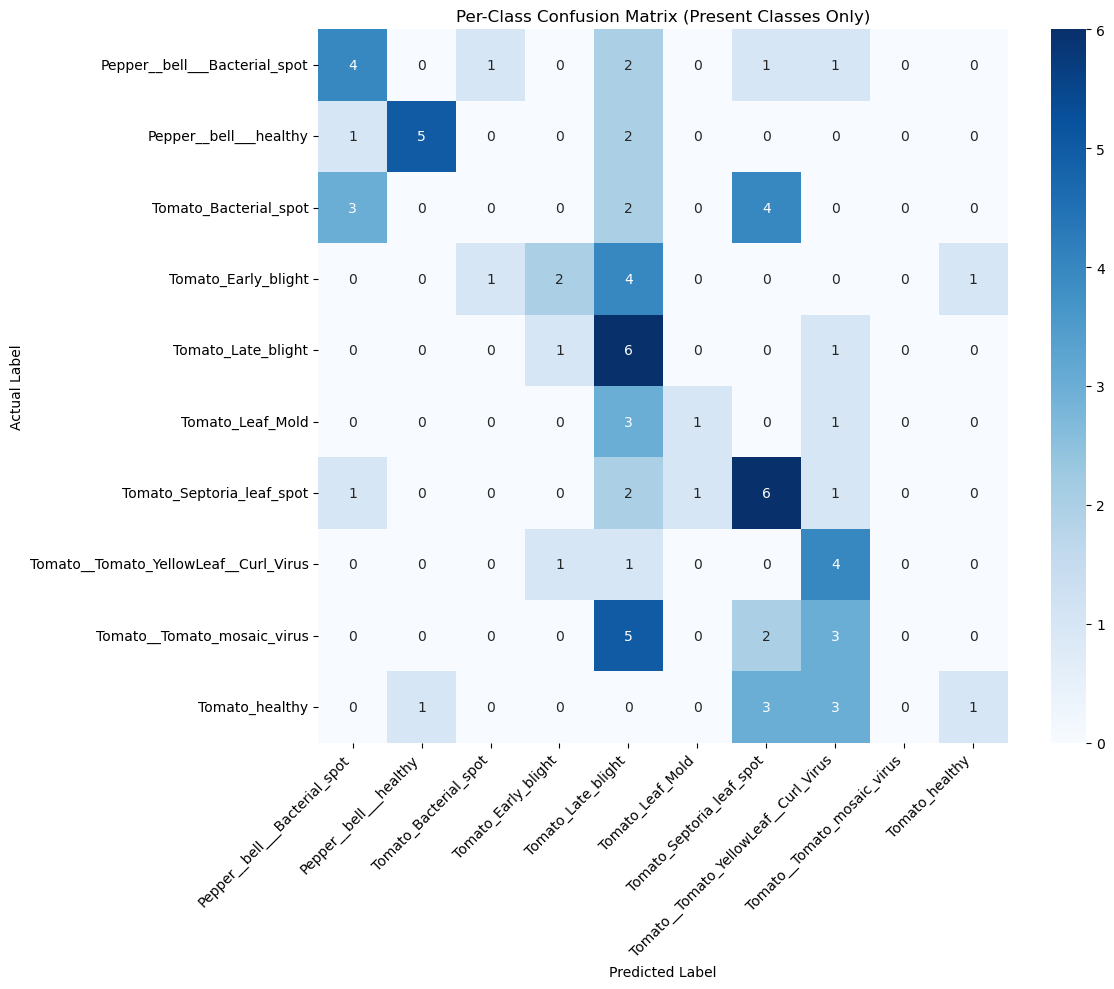

In [83]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
def final_evaluation(model, loader, device, source_idx_map):
    model.eval()
    all_preds = []
    all_labels = []
    
    inv_map = {v: k for k, v in source_idx_map.items()}

    print("\n Running Final Metrics...")
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Testing"):
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, dim=1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    # --- THE FIX STARTS HERE ---
    # Find which class IDs actually exist in the test labels
    unique_labels = np.unique(all_labels)
    # Get the names for ONLY those labels, in order
    present_class_names = [inv_map[i] for i in unique_labels]

    # 1. Calculate Metrics
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    print(f"\n RESULTS ")
    print(f"Overall Accuracy: {acc*100:.2f}%")
    print(f"Macro F1 Score:   {f1:.4f}")
    
    # 2. Detailed Per-Class Report (Passing labels=unique_labels is key)
    print("\n📝 Detailed Classification Report:")
    print(classification_report(all_labels, all_preds, 
                                labels=unique_labels, 
                                target_names=present_class_names))

    # 3. Confusion Matrix Visualization
    cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=present_class_names, yticklabels=present_class_names)
    plt.title('Per-Class Confusion Matrix (Present Classes Only)')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# Execute
final_evaluation(model, test_loader, device, source_idx_map)

In [84]:
def sanity_check(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    
    print(" Running Sanity Check on Training Data (PlantVillage)...")
    with torch.no_grad():
        # Just check the first 20 batches to save time
        for i, (images, labels) in enumerate(loader):
            if i > 20: break 
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f" Sanity Check Accuracy: {acc:.2f}%")
    
    if acc > 80:
        print(" Result: The model IS smart, but PlantDoc is just too different.")
    else:
        print(" Result: The model didn't learn its own training data. Check your optimizer/labels.")

# Execute
sanity_check(model, source_loader, device)

 Running Sanity Check on Training Data (PlantVillage)...
 Sanity Check Accuracy: 86.61%
 Result: The model IS smart, but PlantDoc is just too different.


In [85]:
# Check if the labels we think we are using match the folders
print("Dataset Classes:", source_dataset.classes)
print("Our Label Map Targets:", list(set(label_map.values())))

Dataset Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Our Label Map Targets: ['Tomato_healthy', 'Tomato_Bacterial_spot', 'Tomato_Late_blight', 'Tomato_Septoria_leaf_spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Leaf_Mold', 'Tomato_Early_blight', 'Pepper__bell___healthy', 'Pepper__bell___Bacterial_spot', 'Tomato__Tomato_mosaic_virus']
